# VM Selection Debug
Check how many VMs are on overloaded hosts, because if theres only a few overloaded hosts and only a few vms on them, MM and RC will most likely choose the same ones to migrate

In [1]:
import duckdb as ddb
con = ddb.connect(database=':memory:')
con.execute(f"""CREATE OR REPLACE VIEW node_snapshot AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/processed/node_snapshot.parquet')""")

In [14]:
node_snapshot = con.query("""SELECT timestamp, node_name, cpu_usage_percent, vm_count, vm_power_allocated FROM node_snapshot""").to_df()


# !!!!
overloaded nodes NEVER have more than 1 VM allocated on them

In [13]:
overloaded_zeros = overloaded[overloaded["vm_count"] == 0]
overloaded_one = overloaded[overloaded["vm_count"] == 1]
overloaded_two_or_more = overloaded[overloaded["vm_count"] > 1]
print(overloaded_zeros.shape, overloaded_one.shape, overloaded_two_or_more.shape)

(49117, 4) (37838, 4) (0, 4)


In [14]:
overloaded_one.head(30)

,timestamp,cpu_usage_percent,vm_count,vm_power_allocated
45784,2025-01-15 09:21:00+01:00,97.96,1,387.51
45790,2025-01-15 09:24:00+01:00,99.93,1,387.51
45796,2025-01-15 09:27:00+01:00,100.00,1,387.51
45802,2025-01-15 09:30:00+01:00,99.97,1,387.51
45807,2025-01-15 09:33:00+01:00,99.93,1,387.51
45812,2025-01-15 09:36:00+01:00,99.97,1,387.51
45816,2025-01-15 09:39:00+01:00,100.00,1,387.51
45821,2025-01-15 09:42:00+01:00,99.95,1,387.51
45825,2025-01-15 09:45:00+01:00,99.91,1,387.51
45830,2025-01-15 09:48:00+01:00,100.00,1,387.51


Another doubt is: maybe some nodes become underloaded after vm is removed and then all other vms are also removed? or maybe not because it checks for the largest smallest vm to go under the threshold

In [18]:
underloaded_10 = node_snapshot[node_snapshot["cpu_usage_percent"] < 10]
underloaded_20 = node_snapshot[node_snapshot["cpu_usage_percent"] < 20]
print(underloaded_10.shape, underloaded_20.shape)

(6463700, 4) (6668286, 4)


In [22]:
overloaded_30 = node_snapshot[node_snapshot["cpu_usage_percent"] > 25]
print(overloaded_30.shape)

(689931, 5)


In [23]:
print(overloaded_30[overloaded_30["vm_count"] > 1])

                        timestamp node_name  cpu_usage_percent  vm_count  \
2048969 2025-01-16 09:21:00+01:00  85ebbabd              27.57         8   
2049097 2025-01-16 09:24:00+01:00  85ebbabd              27.49         8   
2049225 2025-01-16 09:27:00+01:00  85ebbabd              27.49         8   
2049353 2025-01-16 09:30:00+01:00  85ebbabd              27.49         8   
2049481 2025-01-16 09:33:00+01:00  85ebbabd              27.49         8   
...                           ...       ...                ...       ...   
6718405 2025-04-02 09:57:00+02:00  43e593b3              27.84        10   
6718533 2025-04-02 10:00:00+02:00  43e593b3              26.20        10   
6718661 2025-04-02 10:03:00+02:00  43e593b3              28.24        10   
6722117 2025-04-02 11:24:00+02:00  43e593b3              28.13        10   
6722501 2025-04-02 11:33:00+02:00  43e593b3              28.08        10   

         vm_power_allocated  
2048969              119.82  
2049097              119.79

In [24]:
overloaded_nodes = overloaded_30.loc[
    overloaded_30["vm_count"] > 1,
    "node_name"
].unique()

print(overloaded_nodes)

<ArrowStringArray>
['85ebbabd', '43e593b3', '1e64c783', 'e2b6ed0e', '7e99a5c6']
Length: 5, dtype: str


In [19]:
underloaded_20 = underloaded_20[underloaded_20["cpu_usage_percent"] > 10]
print(underloaded_20.shape)
underloaded_20


(204495, 4)


,timestamp,cpu_usage_percent,vm_count,vm_power_allocated
4,2024-12-14 01:00:00+01:00,18.52,0,0.00
132,2024-12-14 01:03:00+01:00,17.47,0,0.00
260,2024-12-14 01:06:00+01:00,17.62,0,0.00
388,2024-12-14 01:09:00+01:00,18.59,0,0.00
516,2024-12-14 01:12:00+01:00,18.36,0,0.00
...,...,...,...,...
7390856,2025-04-13 08:57:00+02:00,10.92,1,9.41
7390983,2025-04-13 09:00:00+02:00,10.92,1,9.41
7391110,2025-04-13 09:03:00+02:00,10.89,1,9.41
7394510,2025-04-13 10:24:00+02:00,15.93,1,26.17


In [20]:
underloaded_20_one = underloaded_20[underloaded_20["vm_count"] > 1]
underloaded_20_one

,timestamp,cpu_usage_percent,vm_count,vm_power_allocated
2049090,2025-01-16 09:24:00+01:00,16.57,5,62.99
2049218,2025-01-16 09:27:00+01:00,16.51,5,62.85
2049346,2025-01-16 09:30:00+01:00,16.52,5,62.81
2049474,2025-01-16 09:33:00+01:00,16.49,5,62.76
2049602,2025-01-16 09:36:00+01:00,16.51,5,62.77
...,...,...,...,...
7253486,2025-04-11 02:57:00+02:00,10.26,7,34.66
7253614,2025-04-11 03:00:00+02:00,10.16,7,34.65
7272826,2025-04-11 10:30:00+02:00,13.95,4,24.85
7272954,2025-04-11 10:33:00+02:00,10.27,4,18.43


In [21]:
underloaded_10_one = underloaded_10[underloaded_10["vm_count"] > 1]
underloaded_10_one

,timestamp,cpu_usage_percent,vm_count,vm_power_allocated
119,2024-12-14 01:00:00+01:00,1.07,19,2.52
247,2024-12-14 01:03:00+01:00,0.99,19,2.50
375,2024-12-14 01:06:00+01:00,0.90,19,2.59
503,2024-12-14 01:09:00+01:00,0.87,19,2.42
631,2024-12-14 01:12:00+01:00,1.01,19,2.62
...,...,...,...,...
7434101,2025-04-14 01:57:00+02:00,0.07,7,0.07
7434102,2025-04-14 01:57:00+02:00,0.78,5,1.74
7434103,2025-04-14 01:57:00+02:00,0.15,4,0.30
7434104,2025-04-14 01:57:00+02:00,1.95,16,4.94


In [17]:
overloaded_80 = node_snapshot[
    (node_snapshot["cpu_usage_percent"] >=29) &
    (node_snapshot["vm_count"] > 1)
]

print(overloaded_80)

                        timestamp  cpu_usage_percent  vm_count  \
5807797 2025-03-18 14:54:00+01:00              29.02         8   

         vm_power_allocated  
5807797              125.28  


# Cpu usage percentage distribution: 

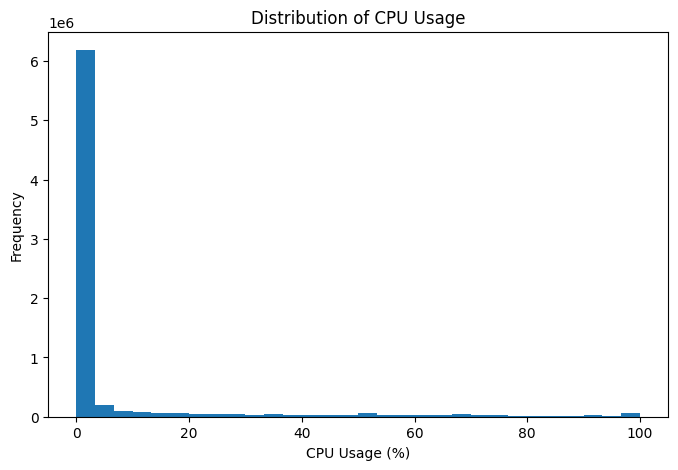

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(node_snapshot["cpu_usage_percent"], bins=30)
plt.xlabel("CPU Usage (%)")
plt.ylabel("Frequency")
plt.title("Distribution of CPU Usage")
plt.show()

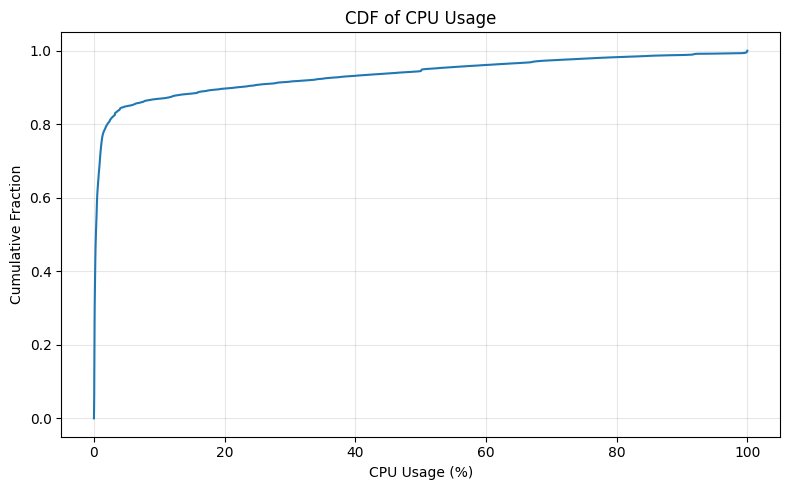

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.sort(node_snapshot["cpu_usage_percent"])
y = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(8,5))
plt.plot(x, y)

plt.xlabel("CPU Usage (%)")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of CPU Usage")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

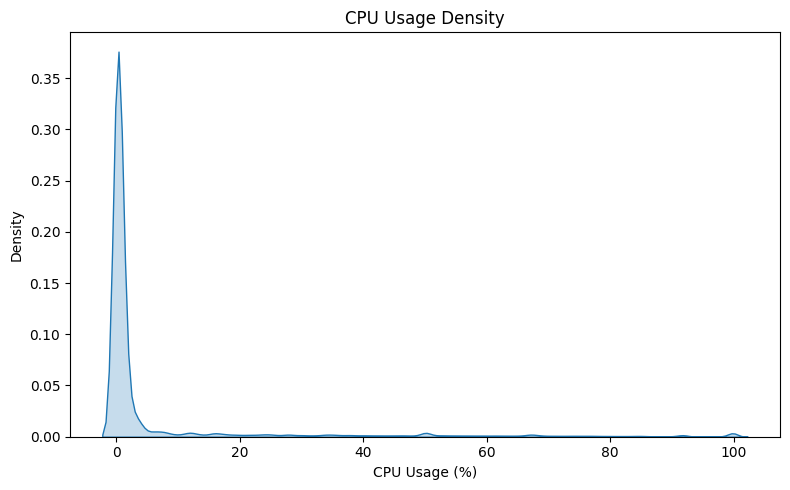

In [6]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=node_snapshot,
    x="cpu_usage_percent",
    fill=True
)

plt.xlabel("CPU Usage (%)")
plt.ylabel("Density")
plt.title("CPU Usage Density")
plt.tight_layout()
plt.show()

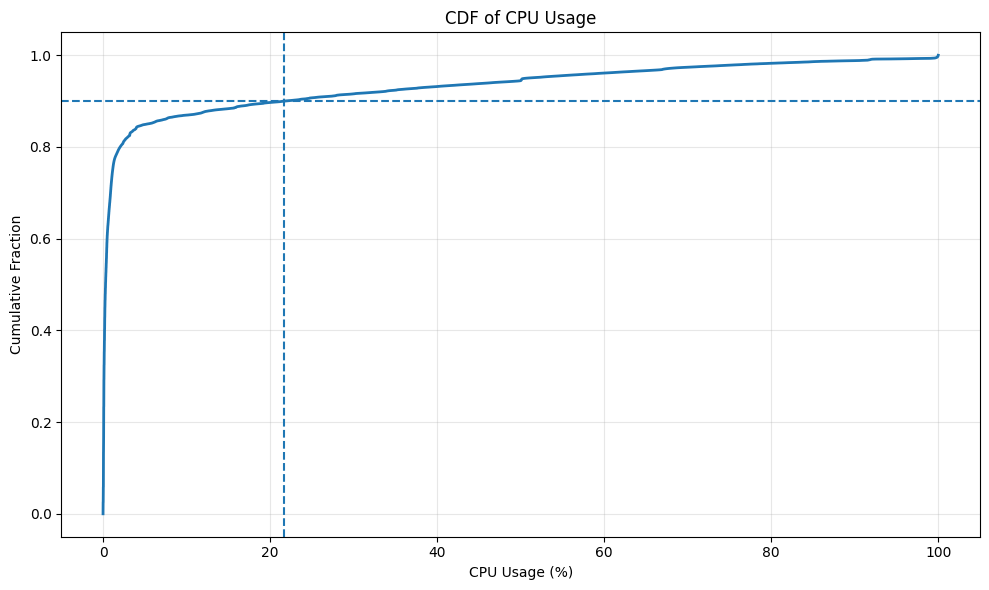

In [8]:
cpu = np.sort(node_snapshot["cpu_usage_percent"])
cdf = np.arange(1, len(cpu)+1) / len(cpu)

plt.figure(figsize=(10,6))
plt.plot(cpu, cdf, linewidth=2)

plt.xlabel("CPU Usage (%)")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of CPU Usage")

plt.grid(True, alpha=0.3)

plt.axhline(0.9, linestyle="--")
plt.axvline(np.percentile(cpu, 90), linestyle="--")

plt.tight_layout()
plt.show()

/var/folders/86/2h31vs451m36tq5zj24mtqdw0000gn/T/ipykernel_19657/2823997668.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


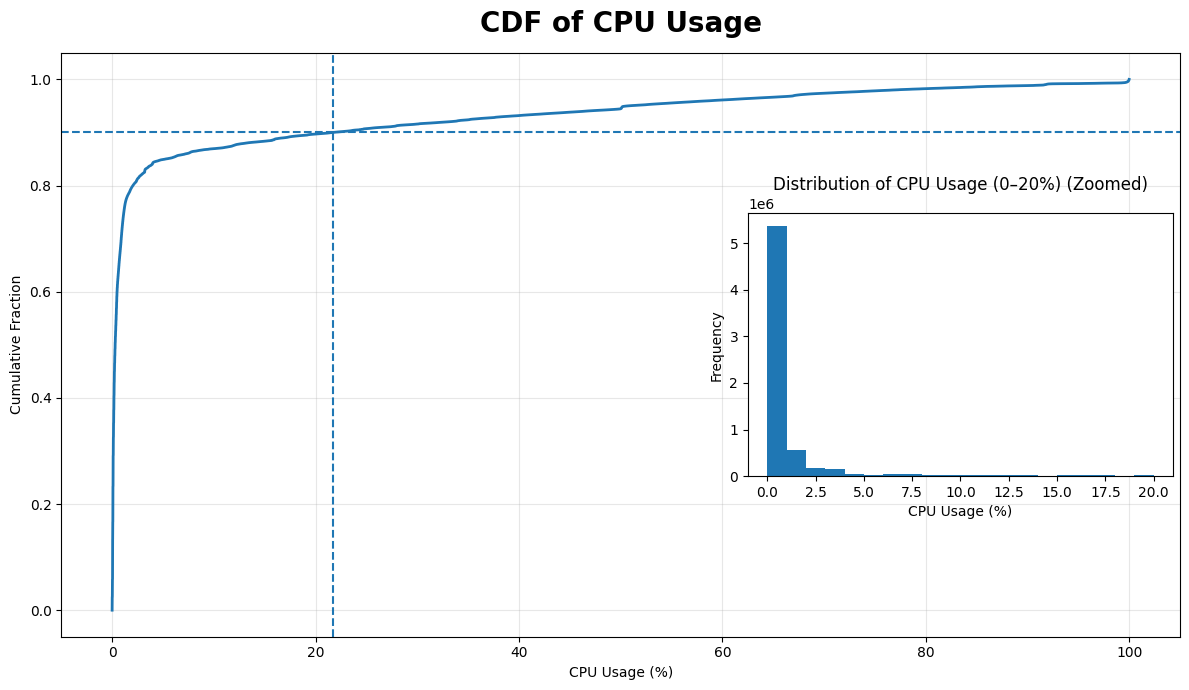

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cpu = np.sort(node_snapshot["cpu_usage_percent"])
cdf = np.arange(1, len(cpu)+1) / len(cpu)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(cpu, cdf, linewidth=2)

ax.set_xlabel("CPU Usage (%)")
ax.set_ylabel("Cumulative Fraction")

ax.grid(True, alpha=0.3)
ax.axhline(0.9, linestyle="--")
ax.axvline(np.percentile(cpu, 90), linestyle="--")

ax.set_title(
    "CDF of CPU Usage",
    fontsize=20,
    fontweight="bold",
    pad=15
)
# Zoomed inset
axins = inset_axes(
    ax,
    width="38%",
    height="45%",
    loc="center right"
)

axins.hist(cpu[cpu <= 20], bins=np.arange(0, 21, 1))

axins.set_title("Distribution of CPU Usage (0–20%) (Zoomed)", fontsize=12)
axins.set_xlabel("CPU Usage (%)", fontsize=10)
axins.set_ylabel("Frequency", fontsize=10)

# Annotation
p90 = np.percentile(cpu, 90)

#text = (
#    f"90% of observations are below "
#    f"{p90:.1f}% CPU utilization."
#)

#fig.text(
#    0.5,
    #0.02,
    #text,
    #ha="center",
    #fontsize=12,
    #bbox=dict(boxstyle="round", alpha=0.15)
#)

plt.tight_layout()
plt.show()

90% of observations are below 21.7% of CPU ultilization